In [1]:
import pandas as pd

dataset link: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml?select=LI-Large_Trans.csv

In [2]:
df = pd.read_csv("/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Small_Trans.csv")
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


In [3]:
df = df.drop(columns=['Timestamp','Account','Account.1'])
df.head()

,From Bank,To Bank,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,11,11,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,3402,3402,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,11,1120,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,3814,3814,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,20,20,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


In [4]:
df.columns

Index(['From Bank', 'To Bank', 'Amount Received', 'Receiving Currency',
       'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 8 columns):
 #   Column              Dtype  
---  ------              -----  
 0   From Bank           int64  
 1   To Bank             int64  
 2   Amount Received     float64
 3   Receiving Currency  object 
 4   Amount Paid         float64
 5   Payment Currency    object 
 6   Payment Format      object 
 7   Is Laundering       int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 422.6+ MB


In [6]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [7]:
df_subset = df.iloc[:4500000].copy()

In [8]:
# Label Encoding for selected columns
label_columns = ['Receiving Currency', 'Payment Currency', 'Payment Format']
label_encoders = {}

In [9]:
for col in label_columns:
    le = LabelEncoder()
    df_subset[col + '_Enc'] = le.fit_transform(df_subset[col])
    label_encoders[col] = le
    # Print the mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Label mapping for {col}:")
    print(mapping)
    print()

Label mapping for Receiving Currency:
{'Australian Dollar': 0, 'Bitcoin': 1, 'Brazil Real': 2, 'Canadian Dollar': 3, 'Euro': 4, 'Mexican Peso': 5, 'Ruble': 6, 'Rupee': 7, 'Saudi Riyal': 8, 'Shekel': 9, 'Swiss Franc': 10, 'UK Pound': 11, 'US Dollar': 12, 'Yen': 13, 'Yuan': 14}

Label mapping for Payment Currency:
{'Australian Dollar': 0, 'Bitcoin': 1, 'Brazil Real': 2, 'Canadian Dollar': 3, 'Euro': 4, 'Mexican Peso': 5, 'Ruble': 6, 'Rupee': 7, 'Saudi Riyal': 8, 'Shekel': 9, 'Swiss Franc': 10, 'UK Pound': 11, 'US Dollar': 12, 'Yen': 13, 'Yuan': 14}

Label mapping for Payment Format:
{'ACH': 0, 'Bitcoin': 1, 'Cash': 2, 'Cheque': 3, 'Credit Card': 4, 'Reinvestment': 5, 'Wire': 6}



In [10]:
df_subset.head()

,From Bank,To Bank,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Receiving Currency_Enc,Payment Currency_Enc,Payment Format_Enc
0,11,11,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0,12,12,5
1,3402,3402,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0,12,12,5
2,11,1120,592571.00,US Dollar,592571.00,US Dollar,Cheque,0,12,12,3
3,3814,3814,12.32,US Dollar,12.32,US Dollar,Reinvestment,0,12,12,5
4,20,20,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0,12,12,5


In [11]:
df_subset.columns

Index(['From Bank', 'To Bank', 'Amount Received', 'Receiving Currency',
       'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering',
       'Receiving Currency_Enc', 'Payment Currency_Enc', 'Payment Format_Enc'],
      dtype='object')

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# Define feature columns and target
X = df_subset[['From Bank', 'To Bank', 'Amount Received', 'Amount Paid',
               'Receiving Currency_Enc', 'Payment Currency_Enc', 'Payment Format_Enc']]
y = df_subset['Is Laundering']

In [14]:
# Split into train and test sets (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [15]:
print(f"Training samples: {X_train.shape[0]}")

Training samples: 3600000


In [16]:
print(f"Testing samples: {X_test.shape[0]}")

Testing samples: 900000


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Predict on test data
y_pred = dt.predict(X_test)

In [19]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")

Decision Tree Accuracy: 0.9992


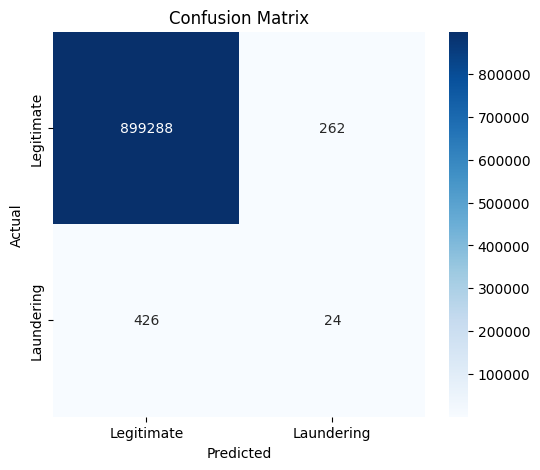

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Laundering'], yticklabels=['Legitimate', 'Laundering'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Classification report
report = classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering'])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    899550
  Laundering       0.08      0.05      0.07       450

    accuracy                           1.00    900000
   macro avg       0.54      0.53      0.53    900000
weighted avg       1.00      1.00      1.00    900000



In [22]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Train the model
rf.fit(X_train, y_train)

# Predict on test data
y_pred = rf.predict(X_test)

In [23]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9995


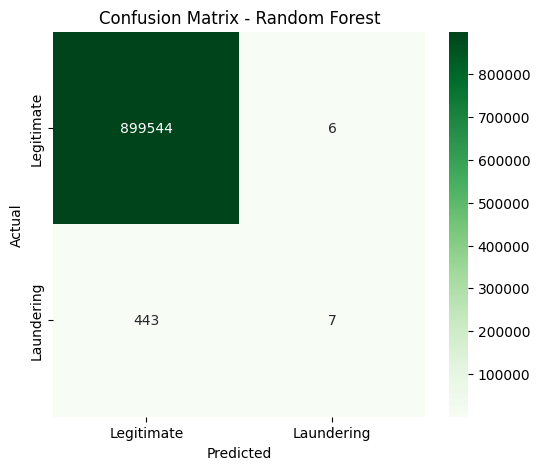

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Legitimate', 'Laundering'], yticklabels=['Legitimate', 'Laundering'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [25]:
# Classification report
report = classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering'])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    899550
  Laundering       0.54      0.02      0.03       450

    accuracy                           1.00    900000
   macro avg       0.77      0.51      0.51    900000
weighted avg       1.00      1.00      1.00    900000



In [27]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN with k=5 (you can adjust k)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# Train the model
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

In [28]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy:.4f}")

KNN Accuracy: 0.9995


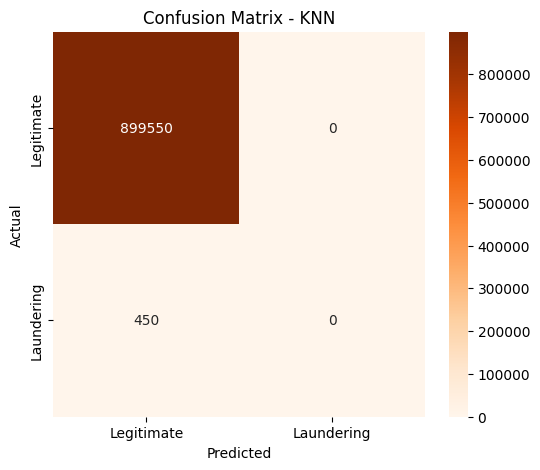

In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Legitimate', 'Laundering'], yticklabels=['Legitimate', 'Laundering'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

In [30]:
# Classification report
report = classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering'])
print("Classification Report:")
print(report)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    899550
  Laundering       0.00      0.00      0.00       450

    accuracy                           1.00    900000
   macro avg       0.50      0.50      0.50    900000
weighted avg       1.00      1.00      1.00    900000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [31]:
from sklearn.svm import SVC

# Initialize SVM with RBF kernel
svm = SVC(kernel='rbf', random_state=42)

# Train the model
svm.fit(X_train, y_train)

# Predict on test data
y_pred = svm.predict(X_test)

In [32]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {accuracy:.4f}")

SVM Accuracy: 0.9995


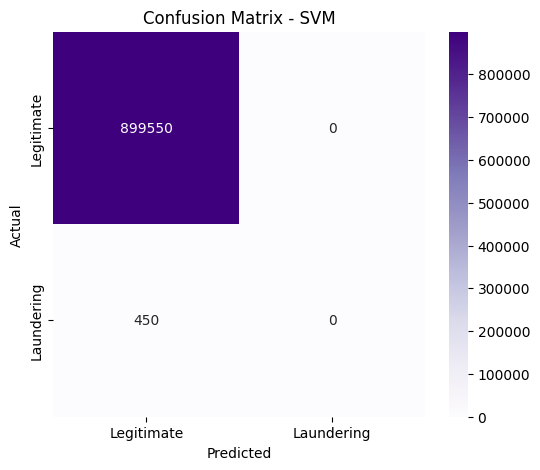

In [33]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Legitimate', 'Laundering'], yticklabels=['Legitimate', 'Laundering'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

In [34]:
# Classification report
report = classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering'])
print("Classification Report:")
print(report)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    899550
  Laundering       0.00      0.00      0.00       450

    accuracy                           1.00    900000
   macro avg       0.50      0.50      0.50    900000
weighted avg       1.00      1.00      1.00    900000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [35]:
import xgboost as xgb

# Initialize XGBoost classifier
xgb_clf = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train the model
xgb_clf.fit(X_train, y_train)

# Predict on test data
y_pred = xgb_clf.predict(X_test)

In [36]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy:.4f}")

XGBoost Accuracy: 0.9995


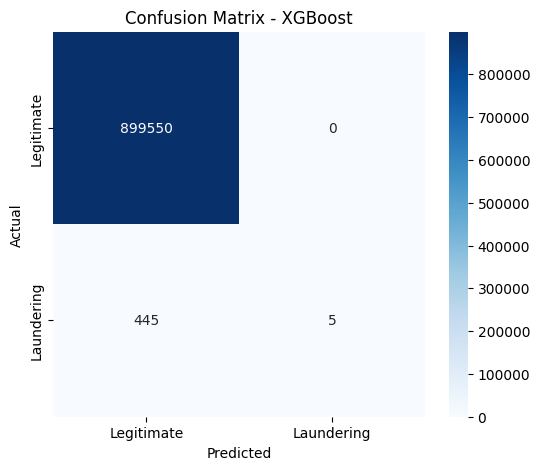

In [37]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Laundering'], yticklabels=['Legitimate', 'Laundering'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [38]:
# Classification report
report = classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering'])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    899550
  Laundering       1.00      0.01      0.02       450

    accuracy                           1.00    900000
   macro avg       1.00      0.51      0.51    900000
weighted avg       1.00      1.00      1.00    900000



In [39]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize AdaBoost classifier
ada = AdaBoostClassifier(random_state=42)

# Train the model
ada.fit(X_train, y_train)

# Predict on test data
y_pred = ada.predict(X_test)

In [40]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Accuracy: {accuracy:.4f}")

AdaBoost Accuracy: 0.9995


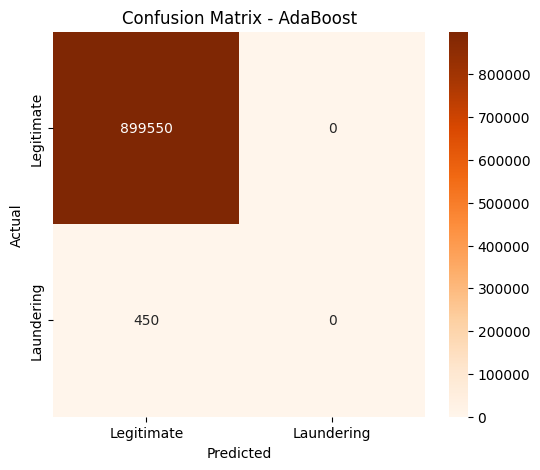

In [41]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Legitimate', 'Laundering'], yticklabels=['Legitimate', 'Laundering'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AdaBoost')
plt.show()

In [42]:
# Classification report
report = classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering'])
print("Classification Report:")
print(report)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    899550
  Laundering       0.00      0.00      0.00       450

    accuracy                           1.00    900000
   macro avg       0.50      0.50      0.50    900000
weighted avg       1.00      1.00      1.00    900000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [44]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.5 MB/s eta 0:00:00


In [45]:
import torch
from torch_geometric.data import Data

In [46]:
# Map unique banks/accounts to node indices
unique_nodes = list(set(df_subset['From Bank']).union(set(df_subset['To Bank'])))
node_id_map = {node: idx for idx, node in enumerate(unique_nodes)}

In [47]:
# Source and target node indices for edges
source_nodes = df_subset['From Bank'].map(node_id_map).to_numpy()
target_nodes = df_subset['To Bank'].map(node_id_map).to_numpy()

In [48]:
# Edge index tensor required by PyG [2, num_edges]
edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)

/tmp/ipykernel_328/2459827691.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)


In [49]:
# Edge features tensor: select numerical columns and encoded categorical
edge_features = df_subset[['Amount Received', 'Amount Paid',
                           'Receiving Currency_Enc', 'Payment Currency_Enc',
                           'Payment Format_Enc']].to_numpy()
edge_attr = torch.tensor(edge_features, dtype=torch.float)

In [50]:
# Edge labels (Is Laundering)
edge_label = torch.tensor(df_subset['Is Laundering'].values, dtype=torch.long)

In [51]:
# Create the PyTorch Geometric Data object
data = Data(x=None, edge_index=edge_index, edge_attr=edge_attr, y=edge_label)

In [52]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv

In [53]:
class EdgeClassificationGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels * 2, 2)  # binary classification (non-laundering, laundering)

    def forward(self, x, edge_index, edge_attr):
        # Node features placeholder (init as zeros if unknown)
        if x is None:
            x = torch.zeros((edge_index.max().item()+1, edge_attr.size(1)), device=edge_attr.device)

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        # For edge classification, concatenate embeddings of source and target nodes
        src, dst = edge_index
        edge_repr = torch.cat([x[src], x[dst]], dim=1)

        out = self.lin(edge_repr)
        return F.log_softmax(out, dim=1)

In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EdgeClassificationGNN(in_channels=edge_attr.size(1), hidden_channels=64).to(device)
data = data.to(device)

In [55]:
device

device(type='cpu')

In [56]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.NLLLoss()

In [57]:
model.train()
for epoch in range(20):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.5974
Epoch 2, Loss: 0.2008
Epoch 3, Loss: 0.0476
Epoch 4, Loss: 0.0106
Epoch 5, Loss: 0.0047
Epoch 6, Loss: 0.0045
Epoch 7, Loss: 0.0051
Epoch 8, Loss: 0.0059
Epoch 9, Loss: 0.0067
Epoch 10, Loss: 0.0074
Epoch 11, Loss: 0.0080
Epoch 12, Loss: 0.0086
Epoch 13, Loss: 0.0092
Epoch 14, Loss: 0.0097
Epoch 15, Loss: 0.0101
Epoch 16, Loss: 0.0105
Epoch 17, Loss: 0.0109
Epoch 18, Loss: 0.0112
Epoch 19, Loss: 0.0114
Epoch 20, Loss: 0.0117


# Disadvantages of Existing System Algorithms

The existing system algorithms include **Decision Tree, Random Forest, KNN, SVM, XGBoost, and AdaBoost**.  
Although their overall accuracy appears extremely high (~99.95%+), a critical inspection of class-level performance reveals significant shortcomings:

---

## Severe Class Imbalance Impact
- The dataset contains a very small number of laundering transactions (**450**) compared to an overwhelming majority of legitimate ones (**899,550**).  
- This extreme imbalance causes the algorithms to achieve high accuracy simply by predicting the majority class, while performing poorly on detecting the minority laundering class.

---

## Very Low Recall for Laundering Class
- Recall for laundering is around **0.00 to 0.05** across most algorithms.  
  - Decision Tree: recall = **0.05**  
  - Random Forest: recall = **0.02**  
  - XGBoost: recall = **0.01**  
- This means the models fail to identify most actual laundering transactions, which is a critical failure for anti-money laundering systems.

---

## Poor F1-score on Laundering Class
- The low F1-scores (**mostly below 0.07**) indicate poor balance between precision and recall for laundering detection.  
- Many models completely fail to detect laundering events despite high overall accuracy.

---

## Overfitting and Over-reliance on Majority Class
- Due to the skewed distribution, models may be overfitting to the majority class pattern.  
- This leads to negligible generalization on illegal transaction detection.

---

## Lack of Meaningful Detection Power on Minority Class
- Algorithms like **KNN, SVM, and AdaBoost** completely fail to detect any laundering transactions (**0 recall**).  
- This makes them practically useless for illicit transaction identification.

---

# Disadvantages Observed in Proposed System Algorithm (SimpleGNN)

## Training Loss Indicates Potential Overfitting or Lack of Convergence
- The **SimpleGNN's training loss** decreases significantly during the first 6 epochs but then starts increasing or fluctuates from epoch 7 to 20.  
  - Loss rises from **0.0045 → 0.0117**.  
- This may indicate the model begins to overfit or is not converging well on the dataset past initial epochs.

---

## No Provided Classification Metrics for GNN
- Without **precision, recall, or F1-score**, the SimpleGNN's true performance on detecting laundering transactions cannot be fully assessed.  
- This is a key limitation.

---

## Potential Model Complexity and Scalability Issues
- **Graph Neural Networks (GNNs)** often have higher computational and memory costs.  
- This might constrain **real-time or large-scale deployment** unless optimized carefully.

---

# Summary

| Aspect                     | Existing System Disadvantages                                            | Proposed System Disadvantages                              |
|-----------------------------|--------------------------------------------------------------------------|------------------------------------------------------------|
| **Minority Class Detection** | Exceptionally poor recall and F1-score on laundering class               | No reported recall/F1 metrics; potential overfitting        |
| **Class Imbalance Handling** | Models biased towards majority class (legitimate)                       | Unclear handling of imbalance in GNN training              |
| **Generalizability**         | Overfitting to legitimate transactions                                  | Training loss behavior suggests potential fitting issues   |
| **Model Interpretability**   | Black-box nature for some models (SVM, AdaBoost, XGBoost)               | GNN models less interpretable than tree-based models       |
| **Real-Time Capability**     | Possibly limited scalability and adaptability                           | Potential computational overhead with complex GNN          |

---

# Conclusion

- Traditional ML algorithms show **excellent numerical accuracy**, but their **actual effectiveness** at detecting money laundering is severely lacking due to **imbalanced data and poor minority class performance**.  
- The proposed **SimpleGNN** model may address some pattern recognition challenges but requires further evaluation of **classification metrics** and careful **training monitoring** to ensure robust detection and generalization.  
- Both systems face limitations related to **real-time adaptability, interpretability, and resilience** to highly imbalanced datasets.
